In [66]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [67]:
path = './Data/smartwatches.csv'

df = pd.read_csv(path)
df.drop_duplicates(inplace=True)
df.drop(['Unnamed: 0'], inplace=True,axis =1)

train_df = df.sample(frac = 0.8 , random_state=2)
test_df = df.drop(train_df.index)
train_df.reset_index()
test_df.reset_index()

train_df.shape , test_df.shape


((360, 15), (90, 15))

In [68]:
train_df.head()


,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
315,fossil,13495.0,NaN,NaN,4.4,11.0,Q Jacqueline,Circle,Silver,Stainless Steel,No,17.5,Yes,1.3 inches,NaN
412,fire-boltt,2399.0,11999.0,80.006667,2.5,6022.0,DAZZLE PLUS,Square,Black,Silicon,Yes,22.0,Yes,1.8 inches,NaN
358,ambrane,2299.0,3999.0,42.510628,4.1,2475.0,Surge 1.28 Curved Display with complete Health...,Circle,Black,Silicon,Yes,22.0,Yes,1.3 inches,NaN
142,apple,44900.0,NaN,NaN,4.6,2847.0,"Watch Series7 (GPS, 45mm) - Blue Aluminium Cas...",Rectangle,Blue,Aluminium,Yes,22.0,Yes,1.8 inches,20 - 35 g
251,garmin,139990.0,NaN,NaN,4.7,6022.0,"Fenix 7X Sapphire Solar, Up to 28 days/37 days...",Circle,Silver,Stainless Steel,Yes,17.5,Yes,0.1 inches,NaN


In [69]:
train_df.isna().sum()

Brand                    0
Current Price            7
Original Price          58
Discount Percentage     58
Rating                   4
Number OF Ratings       47
Model Name              23
Dial Shape              91
Strap Color             91
Strap Material          48
Touchscreen             25
Battery Life (Days)     23
Bluetooth                5
Display Size            22
Weight                 158
dtype: int64

In [70]:
train_df['Display Size'].value_counts().count()

#prints unique values
#only value_counts() prints number of times each unique value is occuring

37

In [71]:
train_df['Display Size'].fillna('0.0 inches' , inplace=True)
train_df['Display Size'].isna().sum()

0

In [72]:
train_df['Display Size'] = train_df['Display Size'].apply(lambda x: float(x.split()[0]))

#lambda function splits string by white spaces and takes the first part of the string (index 0)

In [73]:
train_df['Display Size'].head()

315    1.3
412    1.8
358    1.3
142    1.8
251    0.1
Name: Display Size, dtype: float64

In [74]:
train_df['Display Size'].replace(0.0 , np.nan, inplace=True)
train_df['Display Size'].isna().sum()

23

In [75]:
train_df['Weight'].value_counts()

Weight
20 - 35 g    59
75g +        48
35 - 50 g    46
<= 20 g      34
50 - 75 g    15
Name: count, dtype: int64

In [76]:
re.findall('\d+','35 - 50 g')
#\d+ is used to match for one or more digits

['35', '50']

In [77]:
cal = sum([int(x) for x in re.findall('\d+', '20 - 35 g ')]) / 2
train_df['Weight'].replace('20 - 35 g', cal, inplace=True)

cal = sum([int (x) for x in re.findall('\d+','35 - 50 g')]) / 2
train_df['Weight'].replace('35 - 50 g',cal,inplace=True)

cal = sum([int(x) for x in re.findall('\d+', '50 - 75 g')]) / 2
train_df['Weight'].replace('50 - 75 g', cal, inplace=True)

train_df['Weight'].replace('75g +', float(re.findall('\d+', '75g +')[0]), inplace=True)

train_df['Weight'].replace('<= 20 g', float(re.findall('\d+', '<= 20 g')[0]), inplace=True)

train_df['Weight'].value_counts()

Weight
27.5    59
75.0    48
42.5    46
20.0    34
62.5    15
Name: count, dtype: int64

In [78]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 360 entries, 315 to 229
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                360 non-null    object 
 1   Current Price        353 non-null    float64
 2   Original Price       302 non-null    float64
 3   Discount Percentage  302 non-null    float64
 4   Rating               356 non-null    float64
 5   Number OF Ratings    313 non-null    float64
 6   Model Name           337 non-null    object 
 7   Dial Shape           269 non-null    object 
 8   Strap Color          269 non-null    object 
 9   Strap Material       312 non-null    object 
 10  Touchscreen          335 non-null    object 
 11  Battery Life (Days)  337 non-null    float64
 12  Bluetooth            355 non-null    object 
 13  Display Size         337 non-null    float64
 14  Weight               202 non-null    float64
dtypes: float64(8), object(7)
memory usage: 45.0

In [79]:
train_df['Discount Price'] = (train_df['Original Price'] * (- train_df['Discount Percentage'])) /100

train_df.drop(['Discount Percentage'],inplace=True , axis =1)

In [80]:
train_df.head()

,Brand,Current Price,Original Price,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight,Discount Price
315,fossil,13495.0,NaN,4.4,11.0,Q Jacqueline,Circle,Silver,Stainless Steel,No,17.5,Yes,1.3,NaN,NaN
412,fire-boltt,2399.0,11999.0,2.5,6022.0,DAZZLE PLUS,Square,Black,Silicon,Yes,22.0,Yes,1.8,NaN,-9600.0
358,ambrane,2299.0,3999.0,4.1,2475.0,Surge 1.28 Curved Display with complete Health...,Circle,Black,Silicon,Yes,22.0,Yes,1.3,NaN,-1700.0
142,apple,44900.0,NaN,4.6,2847.0,"Watch Series7 (GPS, 45mm) - Blue Aluminium Cas...",Rectangle,Blue,Aluminium,Yes,22.0,Yes,1.8,27.5,NaN
251,garmin,139990.0,NaN,4.7,6022.0,"Fenix 7X Sapphire Solar, Up to 28 days/37 days...",Circle,Silver,Stainless Steel,Yes,17.5,Yes,0.1,NaN,NaN


Numerical Data


In [81]:
numerical_cols = [feature for feature in train_df.columns if train_df[feature].dtype != 'object']
numerical_cols

['Current Price',
 'Original Price',
 'Rating',
 'Number OF Ratings',
 'Battery Life (Days)',
 'Display Size',
 'Weight',
 'Discount Price']

c:\Users\aarad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\aarad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\aarad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\aarad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

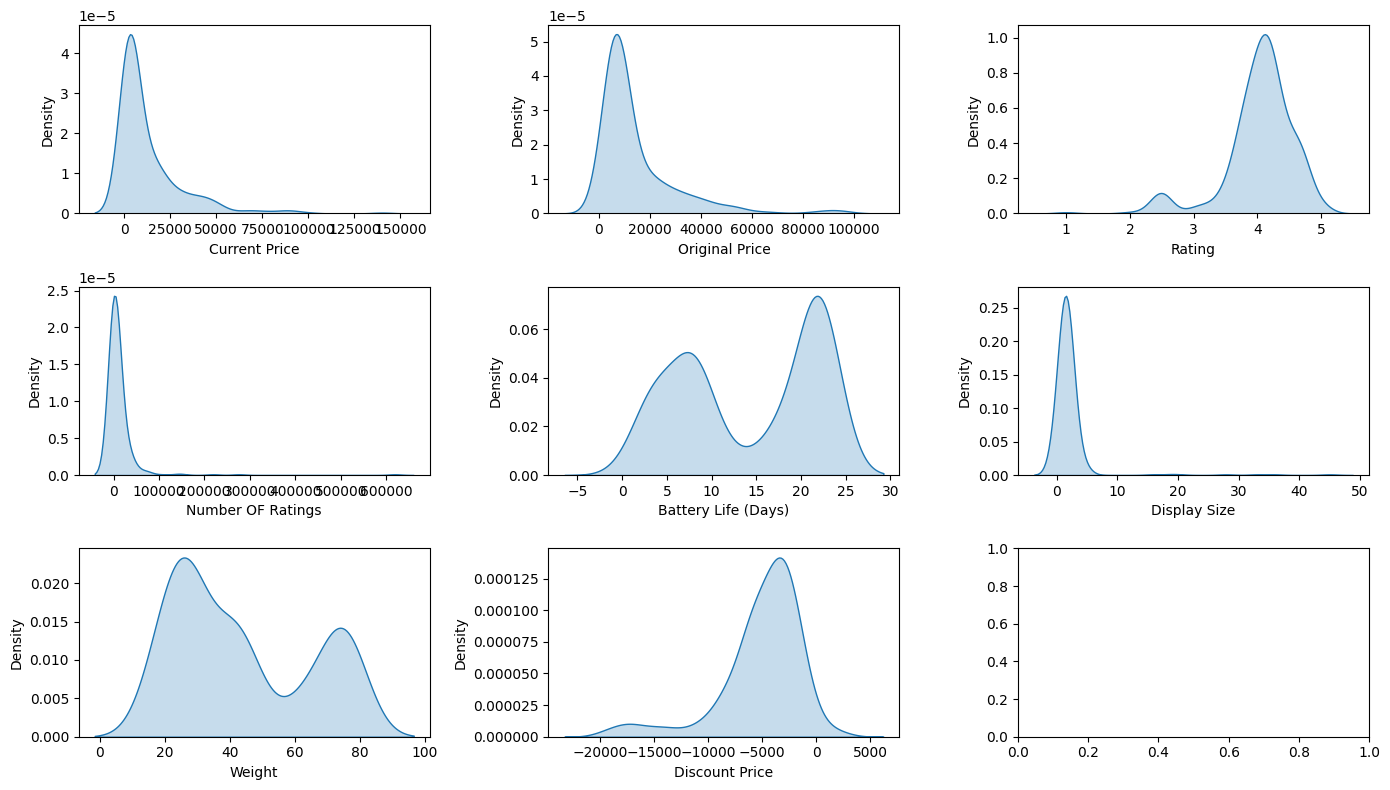

In [82]:
fig , axes = plt.subplots(3,3 , figsize=(14,8))

for i, cols in enumerate(numerical_cols):
    row = i//3
    col = i%3
    ax = axes[row,col]
    sns.kdeplot(data = train_df[cols],ax=ax , fill = True)

fig.tight_layout()
plt.show()

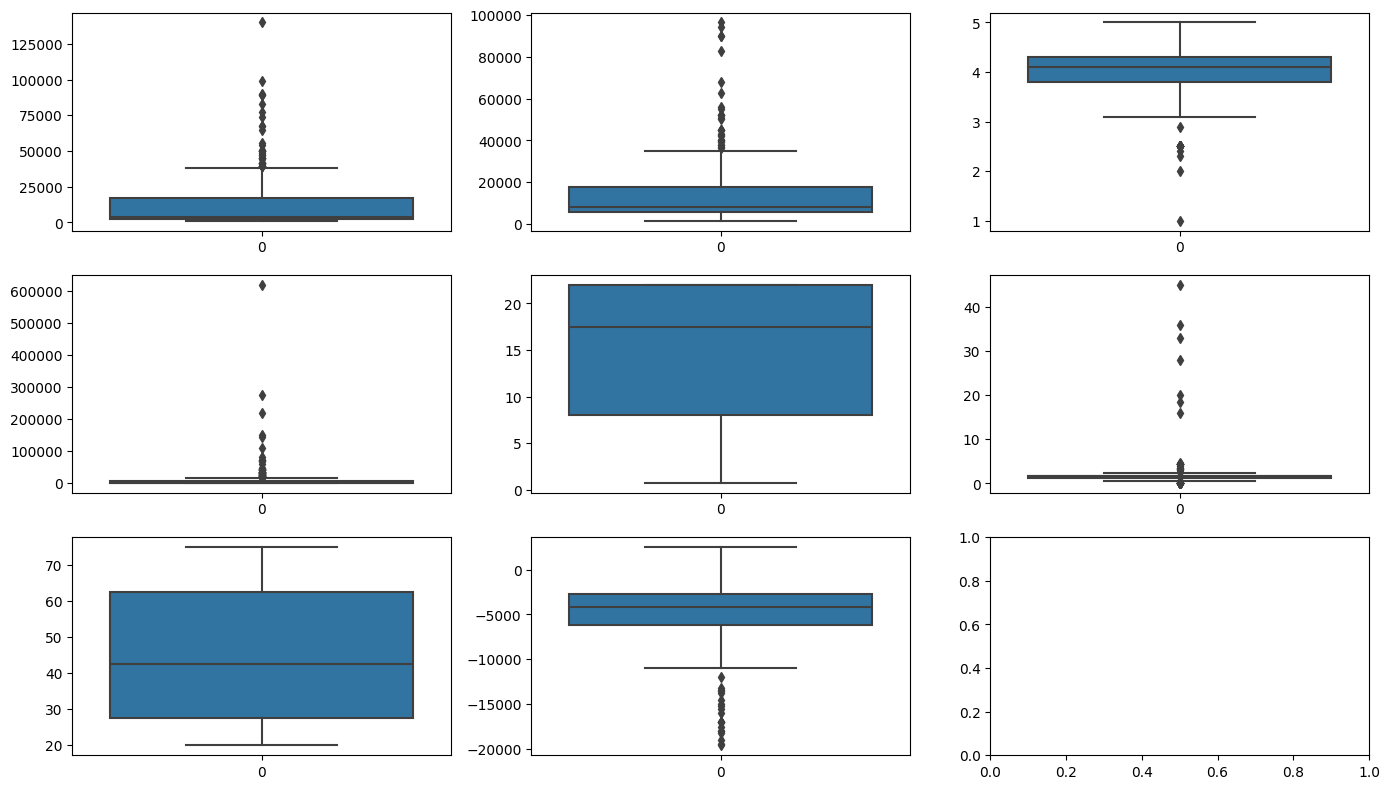

In [83]:
fig , axes = plt.subplots(3,3 , figsize=(14,8))

for i, cols in enumerate(numerical_cols):
    row = i//3
    col = i%3
    ax = axes[row,col]
    sns.boxplot(data = train_df[cols],ax=ax )

fig.tight_layout()
plt.show()

In [84]:
#removing outliers
def remove_outliers_IQR(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[col] > lower_bound) & (data[col] < upper_bound)]


In [85]:
import_col = ['Current Price', 'Original Price', 'Rating', 'Number OF Ratings', 'Display Size']

for col in import_col:
    train_df = remove_outliers_IQR(train_df,col)

In [86]:
for col in numerical_cols:
    train_df[col].fillna(train_df[col].median() , inplace = True)

In [87]:
train_df[numerical_cols].isna().sum()

Current Price          0
Original Price         0
Rating                 0
Number OF Ratings      0
Battery Life (Days)    0
Display Size           0
Weight                 0
Discount Price         0
dtype: int64

using min maxx scaling technique on numerical data except discount prices


In [88]:
from sklearn.preprocessing import MinMaxScaler

In [89]:
scaler = MinMaxScaler()

In [90]:
data = []
data = scaler.fit_transform(train_df[numerical_cols[:-1]])
data

array([[5.55555556e-02, 1.00847097e-01, 6.66666667e-01, 8.54683124e-02,
        1.00000000e+00, 2.30769231e-01, 4.09090909e-01],
       [8.08080808e-02, 1.00847097e-01, 6.66666667e-01, 2.62178889e-01,
        3.41176471e-01, 6.15384615e-01, 1.36363636e-01],
       [4.04040404e-02, 1.95494771e-01, 6.66666667e-01, 3.13867856e-01,
        7.88235294e-01, 6.15384615e-01, 4.09090909e-01],
       [5.05050505e-03, 2.90142445e-01, 7.50000000e-01, 8.91366732e-01,
        3.41176471e-01, 5.38461538e-01, 4.09090909e-01],
       [6.46464646e-01, 8.10704652e-01, 6.66666667e-01, 1.04760917e-02,
        3.41176471e-01, 6.15384615e-01, 1.36363636e-01],
       [4.04040404e-02, 2.89716530e-01, 4.16666667e-01, 7.50994019e-01,
        3.41176471e-01, 5.38461538e-01, 4.09090909e-01],
       [5.20202020e-01, 3.74094932e-01, 7.50000000e-01, 5.87767521e-04,
        5.52941176e-01, 3.07692308e-01, 4.09090909e-01],
       [4.68181818e-02, 1.95494771e-01, 3.33333333e-01, 5.18618401e-04,
        3.41176471e-01, 6

In [91]:
data = pd.DataFrame(data, columns=numerical_cols[:-1])
data

,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Display Size,Weight
0,0.055556,0.100847,0.666667,0.085468,1.000000,0.230769,0.409091
1,0.080808,0.100847,0.666667,0.262179,0.341176,0.615385,0.136364
2,0.040404,0.195495,0.666667,0.313868,0.788235,0.615385,0.409091
3,0.005051,0.290142,0.750000,0.891367,0.341176,0.538462,0.409091
4,0.646465,0.810705,0.666667,0.010476,0.341176,0.615385,0.136364
...,...,...,...,...,...,...,...
126,0.166667,0.195495,0.666667,0.011410,0.341176,0.538462,0.000000
127,0.217172,0.266481,0.500000,0.000657,1.000000,0.615385,0.409091
128,0.015152,0.124509,0.416667,0.046157,0.788235,0.692308,1.000000
129,0.005051,0.100847,0.750000,0.948795,1.000000,0.538462,0.409091


In [92]:
data.shape , train_df.shape

((131, 7), (131, 15))

In [93]:
data.isna().sum()

Current Price          0
Original Price         0
Rating                 0
Number OF Ratings      0
Battery Life (Days)    0
Display Size           0
Weight                 0
dtype: int64

In [94]:
train_df.isna().sum()

Brand                   0
Current Price           0
Original Price          0
Rating                  0
Number OF Ratings       0
Model Name              7
Dial Shape             41
Strap Color            41
Strap Material         19
Touchscreen             4
Battery Life (Days)     0
Bluetooth               0
Display Size            0
Weight                  0
Discount Price          0
dtype: int64

replacing scaled numerical data with existing numerical data in train_df

In [95]:
train_df.drop(numerical_cols[:-1],axis =1,inplace=True)

train_df

,Brand,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Bluetooth,Discount Price
358,ambrane,Surge 1.28 Curved Display with complete Health...,Circle,Black,Silicon,Yes,Yes,-1700.0
328,dizo,Watch Pro,Square,Black,Silicon,Yes,Yes,-1200.0
18,noise,wrb-sw-colorfitultrabuzz-std-blk_blk,NaN,NaN,Other,Yes,Yes,-4000.0
109,fire-boltt,BSW030,NaN,NaN,Silicon,Yes,Yes,-6700.0
243,amazfit,"GTS 3 1,75 HD AMOLED with advanced GPS and 150...",Square,Misty Rose,Silicon,Yes,Yes,-5000.0
...,...,...,...,...,...,...,...,...
239,amazfit,Bip 3 Pro with 1.69 inch Large Color Display B...,Square,Beige,Silicon,Yes,Yes,-1500.0
398,zebronics,UNBEATABLE ZEB-FIT480CH,Square,Black,Silicon,Yes,Yes,-2000.0
372,pebble,"Spark Ace 1.85 Large HD Display, Health Suite,...",Rectangle,Blue,Silicon,Yes,Yes,-3000.0
149,noise,"ColorFit Caliber Go with 1.69 inch HD Display,...",Square,Black,Silicon,Yes,Yes,-2700.0


In [96]:
train_df.shape , data.shape

((131, 8), (131, 7))

In [97]:
train_df = pd.concat([train_df.reset_index(),data],axis=1)

train_df.shape

(131, 16)

In [98]:
train_df.columns

Index(['index', 'Brand', 'Model Name', 'Dial Shape', 'Strap Color',
       'Strap Material', 'Touchscreen', 'Bluetooth', 'Discount Price',
       'Current Price', 'Original Price', 'Rating', 'Number OF Ratings',
       'Battery Life (Days)', 'Display Size', 'Weight'],
      dtype='object')

In [99]:
train_df.head()

,index,Brand,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Bluetooth,Discount Price,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Display Size,Weight
0,358,ambrane,Surge 1.28 Curved Display with complete Health...,Circle,Black,Silicon,Yes,Yes,-1700.0,0.055556,0.100847,0.666667,0.085468,1.000000,0.230769,0.409091
1,328,dizo,Watch Pro,Square,Black,Silicon,Yes,Yes,-1200.0,0.080808,0.100847,0.666667,0.262179,0.341176,0.615385,0.136364
2,18,noise,wrb-sw-colorfitultrabuzz-std-blk_blk,NaN,NaN,Other,Yes,Yes,-4000.0,0.040404,0.195495,0.666667,0.313868,0.788235,0.615385,0.409091
3,109,fire-boltt,BSW030,NaN,NaN,Silicon,Yes,Yes,-6700.0,0.005051,0.290142,0.750000,0.891367,0.341176,0.538462,0.409091
4,243,amazfit,"GTS 3 1,75 HD AMOLED with advanced GPS and 150...",Square,Misty Rose,Silicon,Yes,Yes,-5000.0,0.646465,0.810705,0.666667,0.010476,0.341176,0.615385,0.136364


In [100]:
train_df[numerical_cols]

,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Display Size,Weight,Discount Price
0,0.055556,0.100847,0.666667,0.085468,1.000000,0.230769,0.409091,-1700.0
1,0.080808,0.100847,0.666667,0.262179,0.341176,0.615385,0.136364,-1200.0
2,0.040404,0.195495,0.666667,0.313868,0.788235,0.615385,0.409091,-4000.0
3,0.005051,0.290142,0.750000,0.891367,0.341176,0.538462,0.409091,-6700.0
4,0.646465,0.810705,0.666667,0.010476,0.341176,0.615385,0.136364,-5000.0
...,...,...,...,...,...,...,...,...
126,0.166667,0.195495,0.666667,0.011410,0.341176,0.538462,0.000000,-1500.0
127,0.217172,0.266481,0.500000,0.000657,1.000000,0.615385,0.409091,-2000.0
128,0.015152,0.124509,0.416667,0.046157,0.788235,0.692308,1.000000,-3000.0
129,0.005051,0.100847,0.750000,0.948795,1.000000,0.538462,0.409091,-2700.0


Categorical Data


In [114]:
categorical_cols = [feature for feature in train_df.columns if train_df[feature].dtype == 'object']
categorical_cols

['Brand',
 'Model Name',
 'Dial Shape',
 'Strap Color',
 'Strap Material',
 'Touchscreen',
 'Bluetooth']

In [115]:
train_df['Bluetooth'].value_counts()

Bluetooth
Yes    131
Name: count, dtype: int64

In [116]:
categorical_cols.remove('Bluetooth')

In [117]:
from scipy.stats import f_oneway

In [122]:
for col in categorical_cols:
    CategoryGroupLists = train_df.groupby(col)['Discount Price'].apply(list)
    AnovaResults = f_oneway(*CategoryGroupLists)
    print(col, ': ','P-Value for anova is: ',AnovaResults[-1])

Brand :  P-Value for anova is:  3.255820837467186e-12
Model Name :  P-Value for anova is:  0.0
Dial Shape :  P-Value for anova is:  0.0002984921220235391
Strap Color :  P-Value for anova is:  0.3506998902441159
Strap Material :  P-Value for anova is:  0.0060135883035738885


c:\Users\aarad\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:4167: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))


TypeError: at least two inputs are required; got 1.

In [ ]:
print(CategoryGroupLists[0])

[-5999.9999993316005, -2999.9999999785, -6000.00000095]


C:\Users\aarad\AppData\Local\Temp\ipykernel_13992\1835541526.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(CategoryGroupLists[0])


In [ ]:
print(AnovaResults)

F_onewayResult(statistic=2.8918955420943018, pvalue=0.0060135883035738885)


In [150]:
imp_col = ['Brand', 'Model Name', 'Dial Shape', 'Strap Material']
train_df[imp_col]

,Brand,Model Name,Dial Shape,Strap Material
0,ambrane,Surge 1.28 Curved Display with complete Health...,Circle,Silicon
1,dizo,Watch Pro,Square,Silicon
2,noise,wrb-sw-colorfitultrabuzz-std-blk_blk,other,Other
3,fire-boltt,BSW030,other,Silicon
4,amazfit,"GTS 3 1,75 HD AMOLED with advanced GPS and 150...",Square,Silicon
...,...,...,...,...
126,amazfit,Bip 3 Pro with 1.69 inch Large Color Display B...,Square,Silicon
127,zebronics,UNBEATABLE ZEB-FIT480CH,Square,Silicon
128,pebble,"Spark Ace 1.85 Large HD Display, Health Suite,...",Rectangle,Silicon
129,noise,"ColorFit Caliber Go with 1.69 inch HD Display,...",Square,Silicon


In [154]:

for col in imp_col:
    print(train_df[col].value_counts())

Brand
noise         20
boat          17
dizo          14
honor         13
fire-boltt    11
pebble        10
gizmore        9
amazfit        7
zebronics      7
ambrane        6
fossil         6
huawei         6
fitbit         3
crossbeats     2
Name: count, dtype: int64
Model Name
other                                                                              7
Wave Call                                                                          3
BSW043                                                                             2
BSW070                                                                             2
Watch Flash                                                                        2
                                                                                  ..
ColorFit Loop Advanced BT Calling with 1.85" display,130+Sports Modes              1
ColorFit Pro4 Max 1.8" BT Calling, Noise detection, Noise Health Suite             1
bsw016                                 

In [143]:
train_df['Brand'].isna().sum()

0

In [139]:
for col in imp_col:
    train_df[col].fillna('other', inplace=True)

In [140]:
train_df[imp_col].isna().sum()

Brand             0
Model Name        0
Dial Shape        0
Strap Material    0
dtype: int64

In [145]:
brand = pd.get_dummies(train_df['Brand'])

model_name  = pd.get_dummies(train_df['Model Name']).drop(['other'], axis=1)
dial_shape = pd.get_dummies(train_df['Dial Shape']).drop(['other'], axis=1)
strap_material = pd.get_dummies(train_df['Strap Material']).drop(['other'], axis=1)

In [149]:
imp_df = pd.concat([brand, model_name , dial_shape, strap_material],axis=1)
imp_df = imp_df.astype(int)
imp_df.head()

,amazfit,ambrane,boat,crossbeats,dizo,fire-boltt,fitbit,fossil,gizmore,honor,...,Square,Fluoroelastomer,Leather,Nylon,Other,Plastic,Rubber,Silicon,Stainless Steel,Thermo Plastic Polyurethene
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


In [157]:
new_df = pd.concat([train_df[numerical_cols] , imp_df], axis=1)
new_df.head()

,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Display Size,Weight,Discount Price,amazfit,ambrane,...,Square,Fluoroelastomer,Leather,Nylon,Other,Plastic,Rubber,Silicon,Stainless Steel,Thermo Plastic Polyurethene
0,0.055556,0.100847,0.666667,0.085468,1.000000,0.230769,0.409091,-1700.0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,0.080808,0.100847,0.666667,0.262179,0.341176,0.615385,0.136364,-1200.0,0,0,...,1,0,0,0,0,0,0,1,0,0
2,0.040404,0.195495,0.666667,0.313868,0.788235,0.615385,0.409091,-4000.0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0.005051,0.290142,0.750000,0.891367,0.341176,0.538462,0.409091,-6700.0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0.646465,0.810705,0.666667,0.010476,0.341176,0.615385,0.136364,-5000.0,1,0,...,1,0,0,0,0,0,0,1,0,0


In [158]:
new_df.isna().sum()

Current Price                  0
Original Price                 0
Rating                         0
Number OF Ratings              0
Battery Life (Days)            0
                              ..
Plastic                        0
Rubber                         0
Silicon                        0
Stainless Steel                0
Thermo Plastic Polyurethene    0
Length: 154, dtype: int64

In [ ]:
new_df.to_csv('./data/clean.csv', index=False)